In [10]:
import sys
sys.path.append('..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

!pip install koreanize-matplotlib -q
import koreanize_matplotlib

import lightgbm as lgb
import xgboost as xgb
from catboost import CatBoostClassifier
import joblib, json

# ── 경로 설정 ──
BASE        = '..'
DATA_PATH   = f'{BASE}/data/raw/train.csv'
MODELS_PATH = f'{BASE}/saved_models'
IMG_PATH    = f'{BASE}/images'

train = pd.read_csv(DATA_PATH)
y = train['임신 성공 여부'].values


[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [11]:
# ── 1. 트리 모델 Feature Importance ──

def get_lgbm_importance(model_path_pattern, n_folds=10):
    importances = []
    feat_names = None
    for fold in range(1, n_folds + 1):
        model = joblib.load(f'{model_path_pattern}_fold{fold}.pkl')
        if feat_names is None:
            feat_names = model.booster_.feature_name()
        importances.append(model.booster_.feature_importance(importance_type='gain'))
    return np.mean(importances, axis=0), feat_names

def get_xgb_importance(model_path_pattern, n_folds=10):
    importances = []
    feat_names = None
    for fold in range(1, n_folds + 1):
        model = joblib.load(f'{model_path_pattern}_fold{fold}.pkl')
        scores = model.get_booster().get_score(importance_type='gain')
        if feat_names is None:
            feat_names = list(scores.keys())
        importances.append([scores.get(f, 0) for f in feat_names])
    return np.mean(importances, axis=0), feat_names

def get_cat_importance(model_path_pattern, n_folds=10):
    importances = []
    feat_names = None
    for fold in range(1, n_folds + 1):
        model = joblib.load(f'{model_path_pattern}_fold{fold}.pkl')
        if feat_names is None:
            feat_names = model.feature_names_
        importances.append(model.get_feature_importance())
    return np.mean(importances, axis=0), feat_names

lgbm_imp, feat_names = get_lgbm_importance(f'{MODELS_PATH}/exp_tuned_lgbm_seed42')
xgb_imp,  _          = get_xgb_importance(f'{MODELS_PATH}/exp_tuned_xgb_seed42')
cat_imp,  _          = get_cat_importance(f'{MODELS_PATH}/exp_tuned_cat_seed42')

print(f'피처 수: {len(feat_names)}')
print(f'LGBM imp shape: {lgbm_imp.shape}')
print(f'XGB  imp shape: {xgb_imp.shape}')
print(f'CAT  imp shape: {cat_imp.shape}')

피처 수: 75
LGBM imp shape: (75,)
XGB  imp shape: (68,)
CAT  imp shape: (75,)


ValueError: All arrays must be of the same length

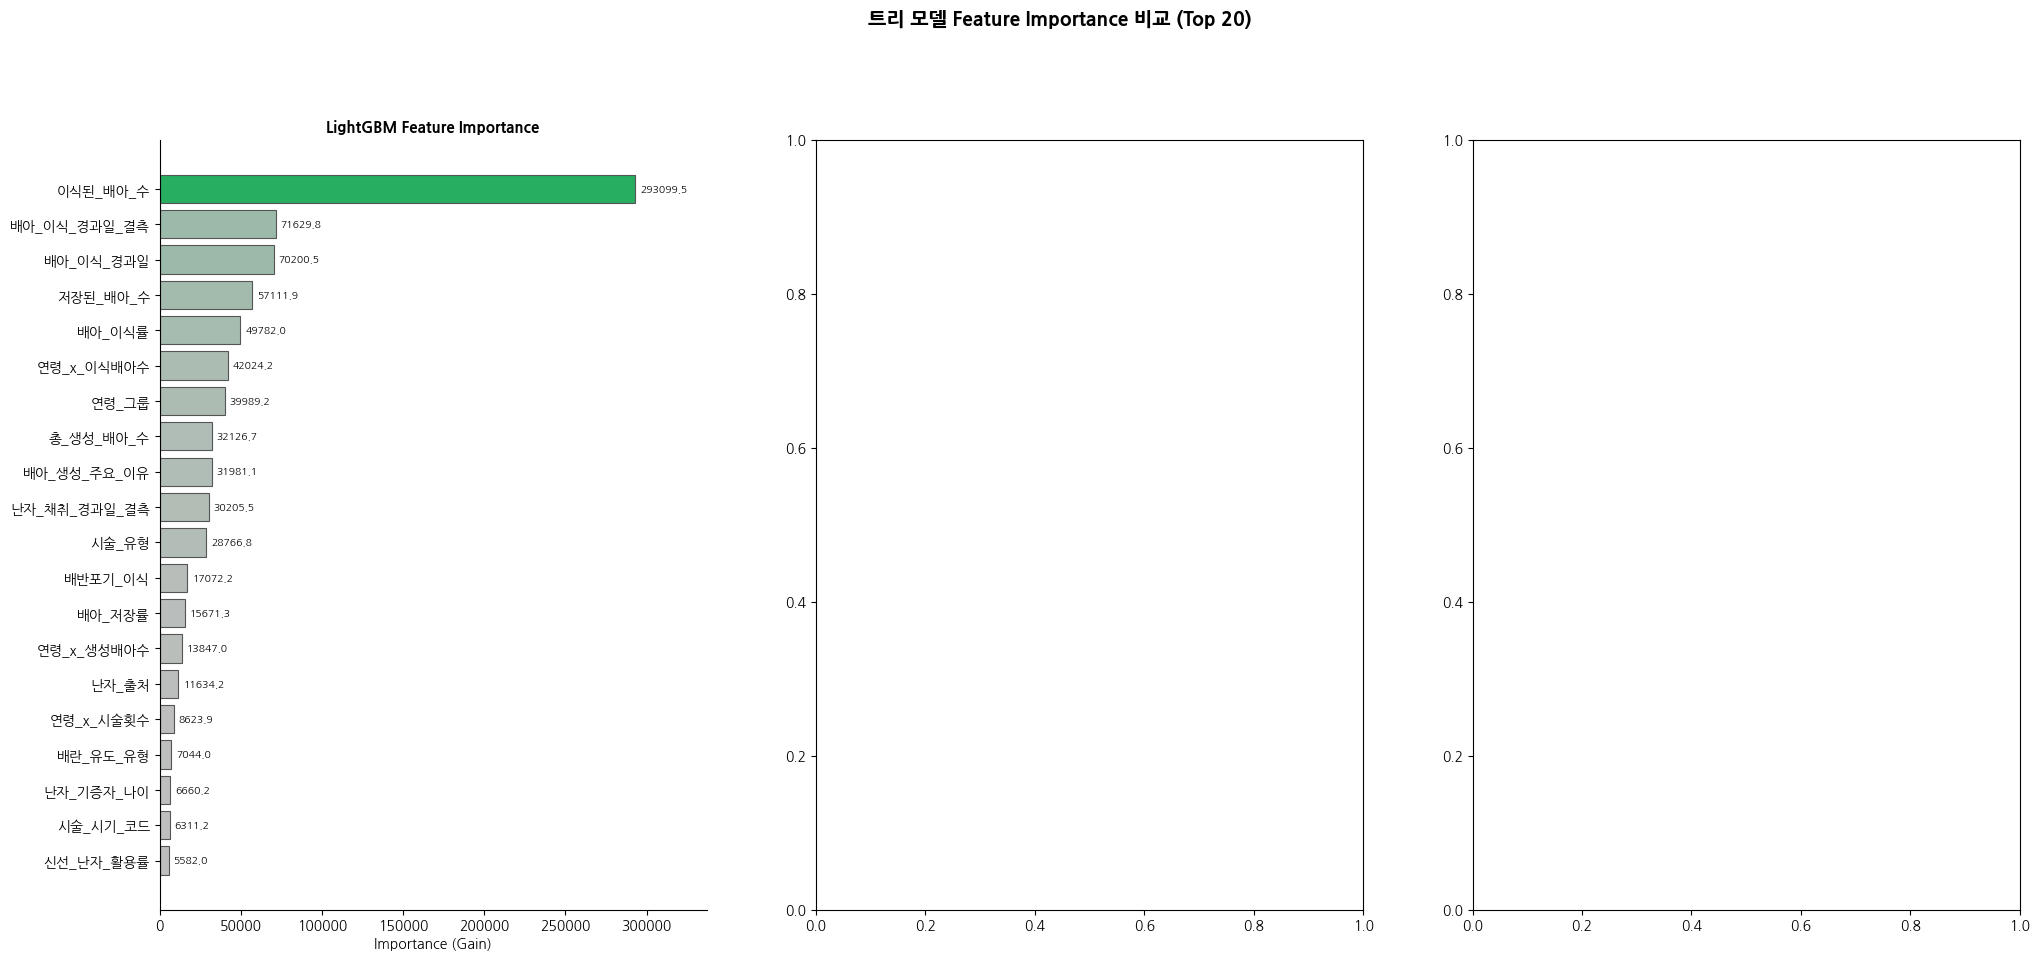

In [12]:
import matplotlib.colors as mcolors

gray_green = mcolors.LinearSegmentedColormap.from_list(
    'gray_green', ['#BEBEBE', '#27AE60']
)

def plot_importance(importance, feature_names, title, ax, top_n=20):
    df = pd.DataFrame({'feature': feature_names, 'importance': importance})
    df = df.sort_values('importance', ascending=False).head(top_n)
    df = df.iloc[::-1].reset_index(drop=True)  # 내림차순 (위가 높은 순)

    norm   = mcolors.Normalize(vmin=df['importance'].min(), vmax=df['importance'].max())
    colors = [gray_green(norm(v)) for v in df['importance']]

    bars = ax.barh(df['feature'], df['importance'],
                   color=colors, edgecolor='#555555', linewidth=0.8)

    for bar, val in zip(bars, df['importance']):
        ax.text(bar.get_width() + df['importance'].max() * 0.01,
                bar.get_y() + bar.get_height() / 2,
                f'{val:.1f}', va='center', fontsize=7.5)

    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlabel('Importance (Gain)')
    ax.set_ylabel('')
    ax.set_xlim(0, df['importance'].max() * 1.15)
    sns.despine(ax=ax)

fig, axes = plt.subplots(1, 3, figsize=(24, 10))
fig.suptitle('트리 모델 Feature Importance 비교 (Top 20)', fontsize=14, fontweight='bold', y=1.01)

plot_importance(lgbm_imp, feat_names, 'LightGBM Feature Importance', axes[0])
plot_importance(xgb_imp,  feat_names, 'XGBoost Feature Importance',  axes[1])
plot_importance(cat_imp,  feat_names, 'CatBoost Feature Importance', axes[2])

plt.tight_layout()
plt.savefig(f'{IMG_PATH}/feature_importance_tree.png', dpi=150, bbox_inches='tight')
plt.show()
print('저장 완료: feature_importance_tree.png')

In [ ]:
import pandas as pd
import numpy as np

train_raw = pd.read_csv(DATA_PATH)
test_raw  = pd.read_csv(f'{BASE}/data/raw/test.csv')

y = train_raw['임신 성공 여부'].values

from src.preprocess import preprocess
from src.features import add_features

train_X, test_X = preprocess(
    train_raw.drop(columns=['임신 성공 여부']),
    test_raw
)

train_X = add_features(train_X)

# FTT / SAINT proxy importance
ftt_oof   = np.load(f'{MODELS_PATH}/exp25_fttransformer_seed42_oof.npy')
saint_oof = np.load(f'{MODELS_PATH}/exp26_saint_seed42_oof.npy')

def get_proxy_importance(oof, X, feat_names):
    imp = {}
    for col in feat_names:
        try:
            corr = np.corrcoef(X[col].fillna(0).values, oof)[0, 1]
            imp[col] = abs(corr)
        except:
            imp[col] = 0
    return np.array([imp[col] for col in feat_names])

ftt_imp   = get_proxy_importance(ftt_oof,   train_X, feat_names)
saint_imp = get_proxy_importance(saint_oof, train_X, feat_names)

print('FTT proxy imp shape:  ', ftt_imp.shape)
print('SAINT proxy imp shape:', saint_imp.shape)

FTT proxy imp shape:   (75,)
SAINT proxy imp shape: (75,)


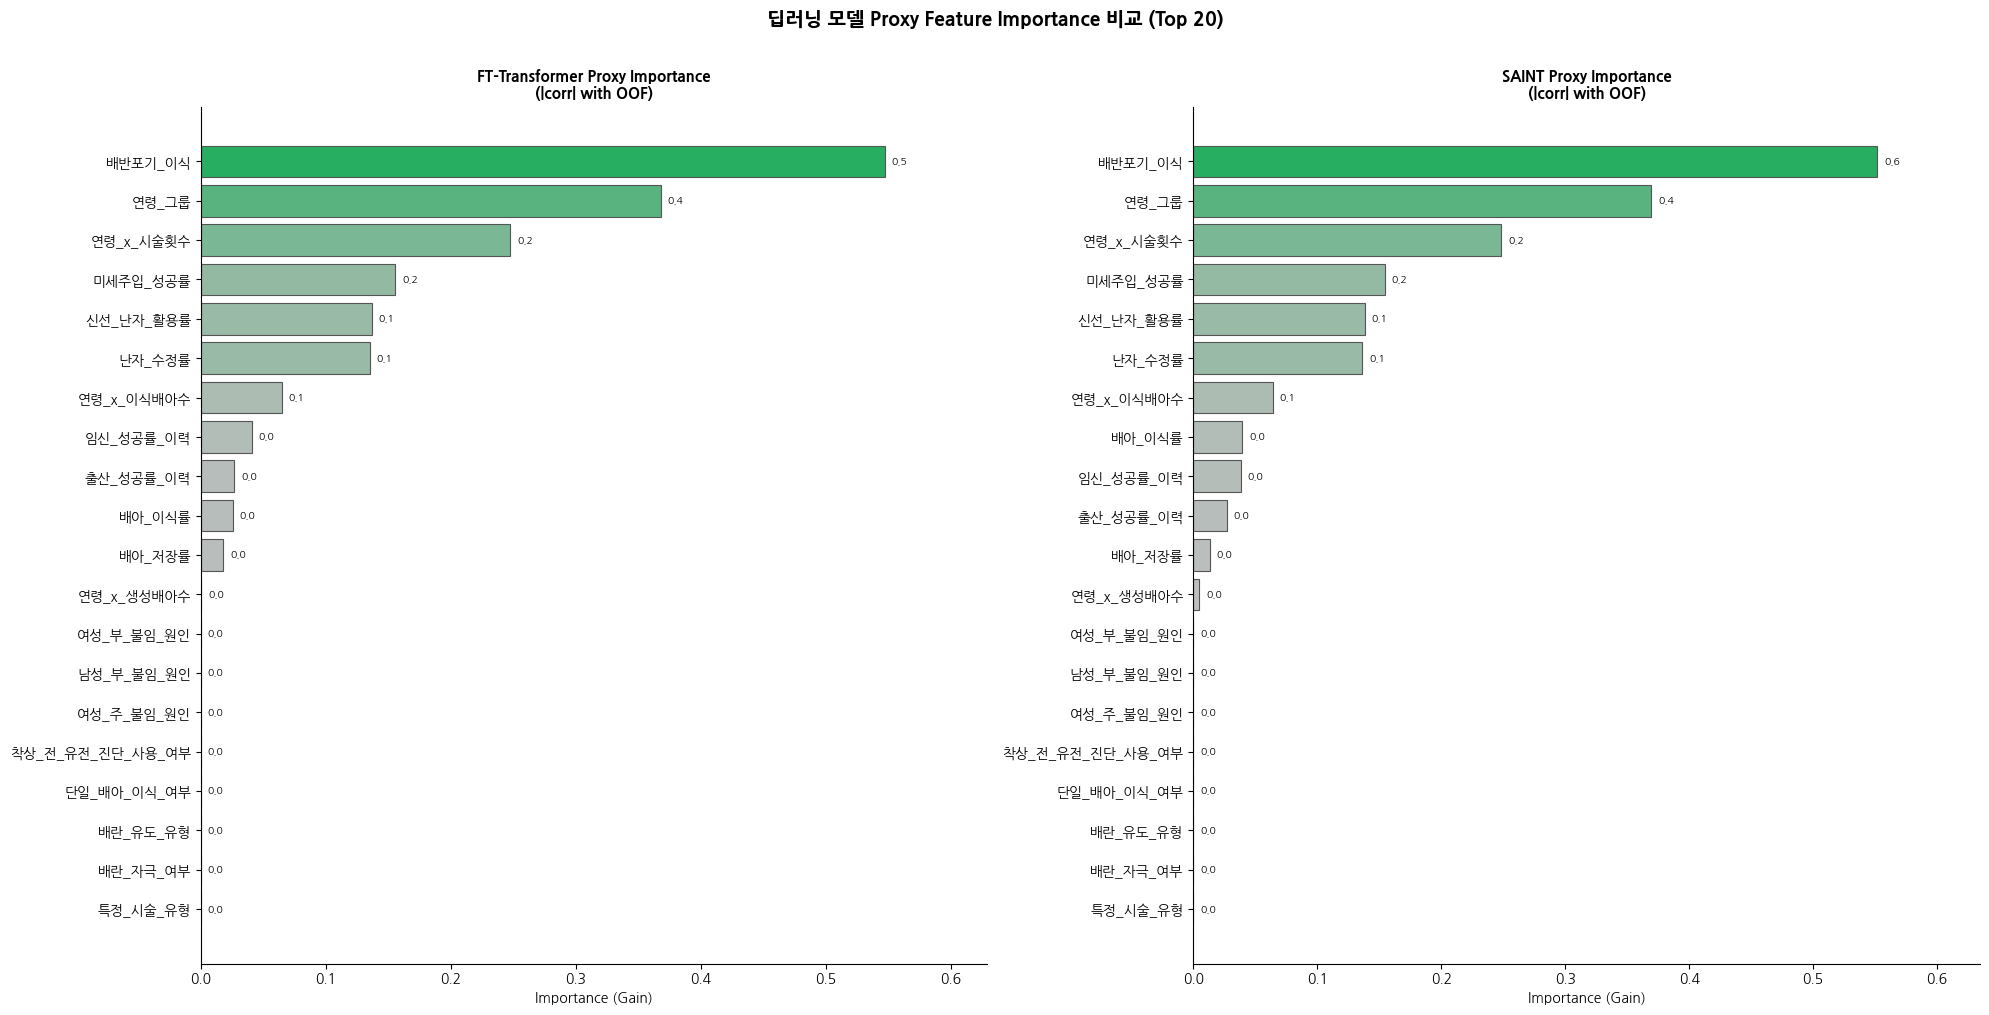

저장 완료: feature_importance_dl.png


In [ ]:
# ── 3. FTT / SAINT Proxy Importance 시각화 ──

fig, axes = plt.subplots(1, 2, figsize=(20, 10))
fig.suptitle('딥러닝 모델 Proxy Feature Importance 비교 (Top 20)', fontsize=14, fontweight='bold', y=1.01)

plot_importance(ftt_imp,   feat_names, 'FT-Transformer Proxy Importance\n(|corr| with OOF)', axes[0])
plot_importance(saint_imp, feat_names, 'SAINT Proxy Importance\n(|corr| with OOF)',          axes[1])

plt.tight_layout()
plt.savefig(f'{IMG_PATH}/feature_importance_dl.png', dpi=150, bbox_inches='tight')
plt.show()
print('저장 완료: feature_importance_dl.png')

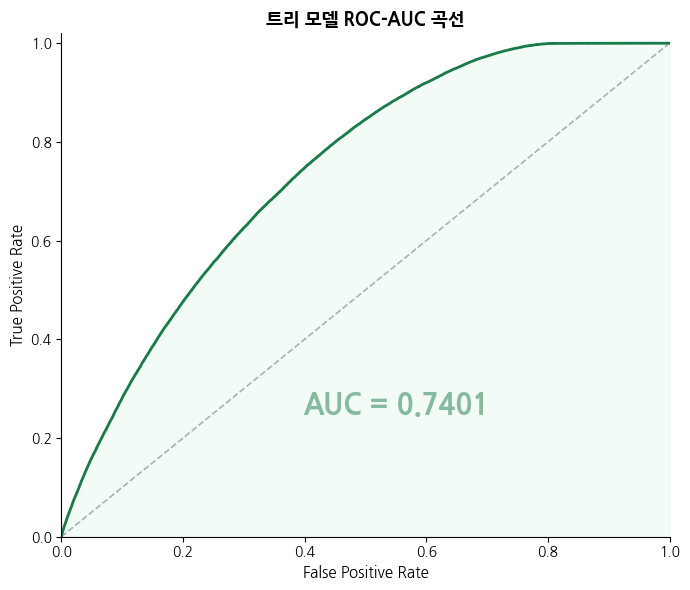

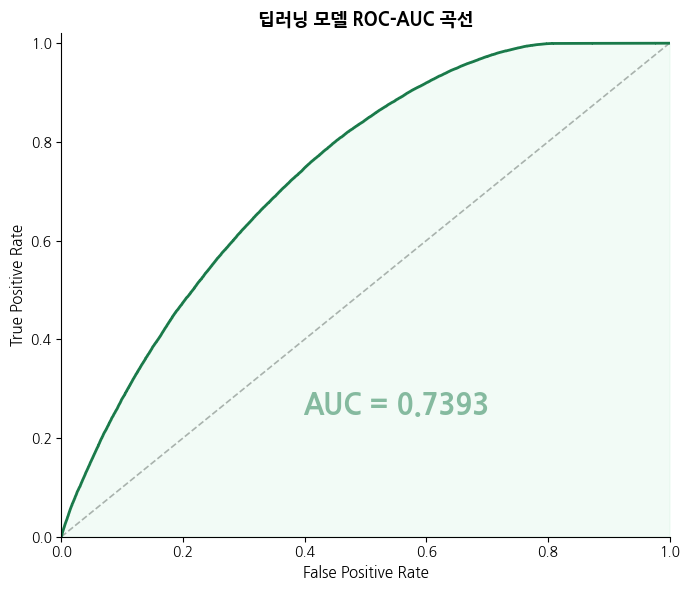

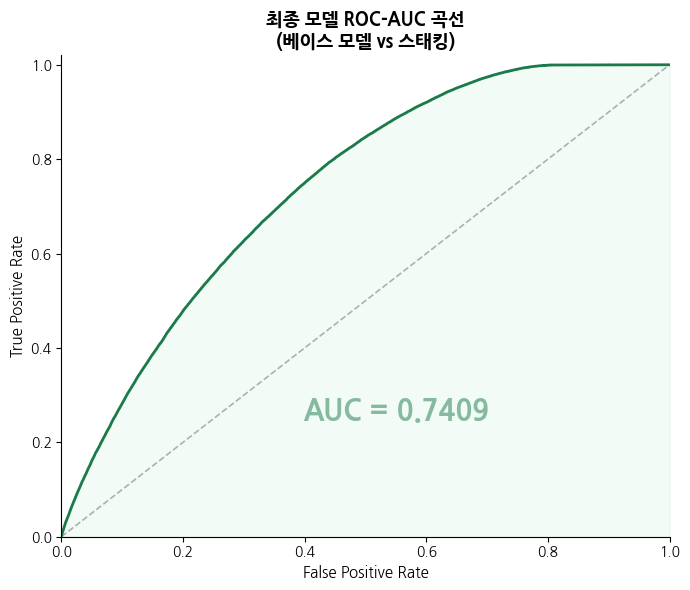

In [24]:
def plot_roc_filled(ax, fpr, tpr, color, fill_color, lw=2.0, fill_alpha=0.15):
    ax.fill_between(fpr, tpr, alpha=fill_alpha, color=fill_color, zorder=1)
    ax.plot(fpr, tpr, color=color, lw=lw, zorder=2)

GREEN_DARK = '#1A7A4A'
GREEN_FILL = '#A8E6C3'
GRAY_DASH  = '#AAAAAA'

# ── 1. 트리 모델 ──
fig, ax = plt.subplots(figsize=(7, 6))

best_auc = max(auc(*roc_curve(y, oof)[:2]) for oof in [lgbm_oof, xgb_oof, cat_oof])
best_oof = max([lgbm_oof, xgb_oof, cat_oof], key=lambda o: auc(*roc_curve(y, o)[:2]))
fpr, tpr, _ = roc_curve(y, best_oof)
plot_roc_filled(ax, fpr, tpr, GREEN_DARK, GREEN_FILL)

ax.plot([0, 1], [0, 1], color=GRAY_DASH, lw=1.2, linestyle='--', zorder=0)
ax.set_xlim([0, 1]); ax.set_ylim([0, 1.02])
ax.set_xlabel('False Positive Rate', fontsize=11)
ax.set_ylabel('True Positive Rate', fontsize=11)
ax.set_title('트리 모델 ROC-AUC 곡선', fontsize=13, fontweight='bold')
ax.text(0.55, 0.25, f'AUC = {best_auc:.4f}',
        fontsize=20, fontweight='bold', color=GREEN_DARK,
        alpha=0.5, ha='center', transform=ax.transData)
sns.despine(ax=ax)
plt.tight_layout()
plt.savefig(f'{IMG_PATH}/roc_auc_tree.png', dpi=150, bbox_inches='tight')
plt.show()

# ── 2. 딥러닝 모델 ──
fig, ax = plt.subplots(figsize=(7, 6))

best_auc_dl = max(auc(*roc_curve(y, oof)[:2]) for oof in [ftt_oof, saint_oof])
best_oof_dl = max([ftt_oof, saint_oof], key=lambda o: auc(*roc_curve(y, o)[:2]))
fpr, tpr, _ = roc_curve(y, best_oof_dl)
plot_roc_filled(ax, fpr, tpr, GREEN_DARK, GREEN_FILL)

ax.plot([0, 1], [0, 1], color=GRAY_DASH, lw=1.2, linestyle='--', zorder=0)
ax.set_xlim([0, 1]); ax.set_ylim([0, 1.02])
ax.set_xlabel('False Positive Rate', fontsize=11)
ax.set_ylabel('True Positive Rate', fontsize=11)
ax.set_title('딥러닝 모델 ROC-AUC 곡선', fontsize=13, fontweight='bold')
ax.text(0.55, 0.25, f'AUC = {best_auc_dl:.4f}',
        fontsize=20, fontweight='bold', color=GREEN_DARK,
        alpha=0.5, ha='center', transform=ax.transData)
sns.despine(ax=ax)
plt.tight_layout()
plt.savefig(f'{IMG_PATH}/roc_auc_dl.png', dpi=150, bbox_inches='tight')
plt.show()

# ── 3. 최종 스태킹 비교 ──
fig, ax = plt.subplots(figsize=(7, 6))

fpr_s, tpr_s, _ = roc_curve(y, meta_oof_pred)
auc_s = auc(fpr_s, tpr_s)
plot_roc_filled(ax, fpr_s, tpr_s, GREEN_DARK, GREEN_FILL)

ax.plot([0, 1], [0, 1], color=GRAY_DASH, lw=1.2, linestyle='--', zorder=0)
ax.set_xlim([0, 1]); ax.set_ylim([0, 1.02])
ax.set_xlabel('False Positive Rate', fontsize=11)
ax.set_ylabel('True Positive Rate', fontsize=11)
ax.set_title('최종 모델 ROC-AUC 곡선\n(베이스 모델 vs 스태킹)', fontsize=13, fontweight='bold')
ax.text(0.55, 0.25, f'AUC = {auc_s:.4f}',
        fontsize=20, fontweight='bold', color=GREEN_DARK,
        alpha=0.5, ha='center', transform=ax.transData)
sns.despine(ax=ax)
plt.tight_layout()
plt.savefig(f'{IMG_PATH}/roc_auc_final.png', dpi=150, bbox_inches='tight')
plt.show()